# UoE MSc AI Dissertation Explorer

Analyze outstanding MSc Artificial Intelligence dissertations from the University of Edinburgh School of Informatics.

**What this notebook does:**
1. Load scraped dissertation data
2. Visualize topic buckets (bar chart + treemap)
3. Word clouds from titles and abstracts
4. Compare trends across academic years
5. Match projects to *your* interests and find under-explored gaps

> **Note:** Data comes from the [outstanding MSc archive](https://project-archive.inf.ed.ac.uk/msc/) only — not the full cohort. Academic year 2024–2025 has no published outstanding projects yet.

In [1]:
# Run once if packages are missing
# !pip install -q pandas matplotlib seaborn plotly wordcloud

In [2]:
from pathlib import Path
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path(".")
RECENT_CSV = DATA_DIR / "uoe_msc_ai_dissertations_with_topics.csv"
EXTENDED_CSV = DATA_DIR / "uoe_msc_ai_dissertations_extended_with_topics.csv"

assert RECENT_CSV.exists(), f"Missing {RECENT_CSV} — run scrape/enrich scripts first"
assert EXTENDED_CSV.exists(), f"Missing {EXTENDED_CSV} — run scrape/enrich scripts first"

## 1. Load & preview data

In [3]:
df_recent = pd.read_csv(RECENT_CSV)
df_extended = pd.read_csv(EXTENDED_CSV)

print(f"Recent (last 2 academic years): {len(df_recent)} projects")
print(f"Extended (all available years): {len(df_extended)} projects")
print("\nAcademic year breakdown (extended):")
display(df_extended["academic_year"].value_counts().to_frame("count"))

df_recent.head(3)

Recent (last 2 academic years): 19 projects
Extended (all available years): 34 projects

Academic year breakdown (extended):


,count
academic_year,
2023-2024,19
2022-2023,15


,academic_year,author,title,project_id,pdf_url,degree_program,is_msc_ai,submission_year,abstract_snippet,source,topic_buckets
0,2023-2024,"Baeza Hirnyak, Ivan",Detecting user radicalization on YouTube using...,20247289,https://project-archive.inf.ed.ac.uk/msc/20247...,MSc Artificial Intelligence,True,2024,Detecting user radicalization on YouTube using...,UoE Informatics Outstanding MSc Archive,"Fairness, Ethics & Society"
1,2023-2024,"Bermejo, Tomas",Automating Systematic Reviews: Generalisation ...,20247282,https://project-archive.inf.ed.ac.uk/msc/20247...,MSc Artificial Intelligence,True,2024,Automating Systematic Reviews: Generalisation ...,UoE Informatics Outstanding MSc Archive,Healthcare & Biology; Education & HCI Tools
2,2023-2024,"Desmitniece, Beate",Graph Neural Network Approach to Census Predic...,20247283,https://project-archive.inf.ed.ac.uk/msc/20247...,MSc Artificial Intelligence,True,2024,Graph Neural Network Approach to Census Predic...,UoE Informatics Outstanding MSc Archive,Reinforcement Learning; Graph & Knowledge


In [4]:
def explode_topics(frame: pd.DataFrame) -> pd.DataFrame:
    """One row per topic tag."""
    rows = []
    for _, row in frame.iterrows():
        topics = [t.strip() for t in str(row["topic_buckets"]).split(";") if t.strip()]
        for topic in topics:
            rows.append({
                "academic_year": row["academic_year"],
                "author": row["author"],
                "title": row["title"],
                "topic": topic,
                "project_id": row["project_id"],
            })
    return pd.DataFrame(rows)

topics_recent = explode_topics(df_recent)
topics_extended = explode_topics(df_extended)
topics_recent.head()

,academic_year,author,title,topic,project_id
0,2023-2024,"Baeza Hirnyak, Ivan",Detecting user radicalization on YouTube using...,"Fairness, Ethics & Society",20247289
1,2023-2024,"Bermejo, Tomas",Automating Systematic Reviews: Generalisation ...,Healthcare & Biology,20247282
2,2023-2024,"Bermejo, Tomas",Automating Systematic Reviews: Generalisation ...,Education & HCI Tools,20247282
3,2023-2024,"Desmitniece, Beate",Graph Neural Network Approach to Census Predic...,Reinforcement Learning,20247283
4,2023-2024,"Desmitniece, Beate",Graph Neural Network Approach to Census Predic...,Graph & Knowledge,20247283


## 2. Topic bucket clusters

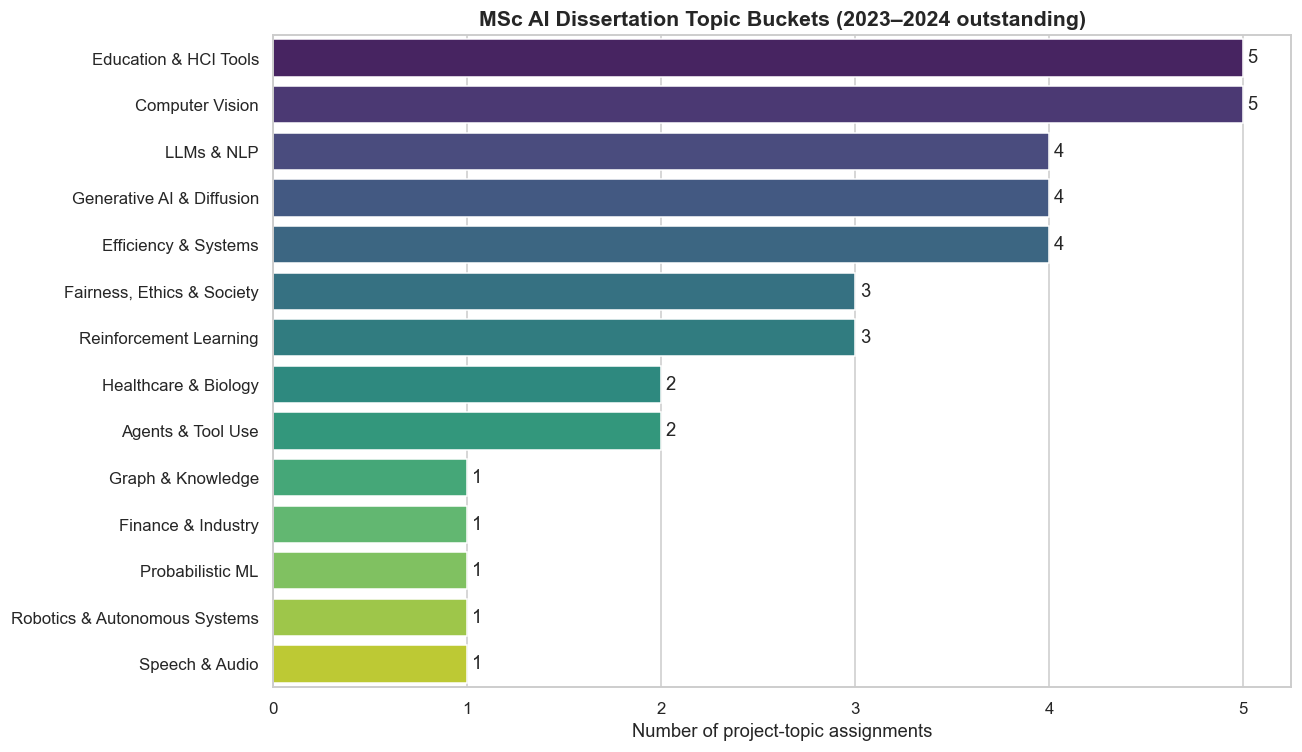

In [5]:
topic_counts = topics_recent["topic"].value_counts().reset_index()
topic_counts.columns = ["topic", "count"]

fig, ax = plt.subplots(figsize=(12, 7))
bars = sns.barplot(data=topic_counts, y="topic", x="count", ax=ax, hue="topic", legend=False, palette="viridis")
ax.set_title("MSc AI Dissertation Topic Buckets (2023–2024 outstanding)", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of project-topic assignments")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

In [6]:
fig = px.treemap(
    topics_recent,
    path=["topic", "title"],
    title="Treemap: Topics → Projects (click to drill down)",
    color="topic",
    color_discrete_sequence=px.colors.qualitative.Set3,
)
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10), height=600)
fig.show()

In [7]:
print("Projects per topic:\n")
for topic, group in topics_recent.groupby("topic"):
    print(f"\n### {topic} ({len(group)})")
    for title in group["title"]:
        print(f"  • {title}")

Projects per topic:


### Agents & Tool Use (2)
  • Reimagining Generative Agents: 3D Architecture
  • Hard-Routed Adapters: Enhancing API Calls in Multi-Agent

### Computer Vision (5)
  • Tree Species Classification with High Resolution Satellite
  • A Visual Solver For Fair Division - Adding
  • Retrofitting Vision Transformers via Fixed and Dynamic
  • Evaluation of 3D Object Detection Models in Autonomous
  • Semi-Supervised Multimodal Polyp Segmentation via Selective

### Education & HCI Tools (5)
  • Automating Systematic Reviews: Generalisation to New
  • Reimagining Generative Agents: 3D Architecture
  • A Visual Solver For Fair Division - Adding
  • Decision Transformer vs. Decision Mamba: Analysing the
  • Browser-Based 3D-Gallery To Showcase Student Work

### Efficiency & Systems (4)
  • Reimagining Generative Agents: 3D Architecture
  • Retrofitting Vision Transformers via Fixed and Dynamic
  • Quantizing Tractable Probabilistic Models
  • Accelerated Decipherment for Zero-

## 3. Word clouds (titles + abstracts)

In [8]:
EXTRA_STOPWORDS = STOPWORDS | {
    "abstract", "university", "edinburgh", "informatics", "school", "science",
    "master", "artificial", "intelligence", "project", "dissertation", "using",
    "based", "approach", "model", "models", "learning", "data", "study",
}

def clean_text_for_wordcloud(text: str) -> str:
    text = re.sub(r"[^A-Za-z0-9\s-]", " ", str(text))
    text = re.sub(r"\s+", " ", text)
    return text.lower()

def make_wordcloud(text: str, title: str):
    wc = WordCloud(
        width=1200,
        height=600,
        background_color="#0f172a",
        colormap="plasma",
        stopwords=EXTRA_STOPWORDS,
        max_words=120,
        collocations=True,
    ).generate(clean_text_for_wordcloud(text))

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold", color="#e2e8f0", pad=12)
    fig.patch.set_facecolor("#0f172a")
    plt.tight_layout()
    plt.show()

TypeError: asarray() got an unexpected keyword argument 'copy'

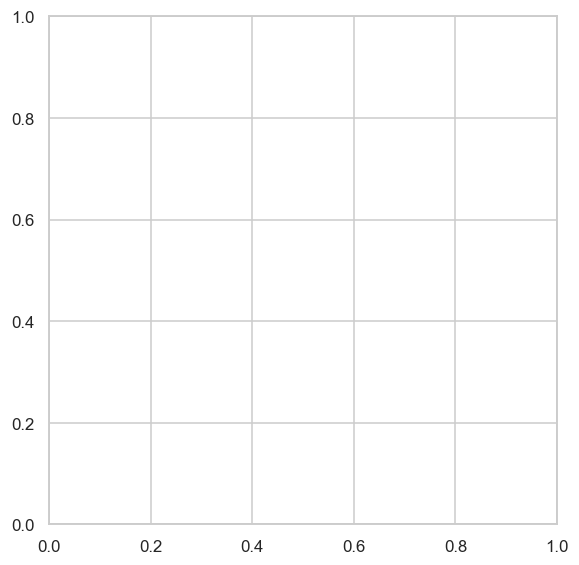

In [9]:
title_text = " ".join(df_extended["title"].dropna())
make_wordcloud(title_text, "Word Cloud — Dissertation Titles (all years)")

In [ ]:
abstract_text = " ".join(df_extended["abstract_snippet"].dropna())
make_wordcloud(abstract_text, "Word Cloud — Abstract Snippets (all years)")

## 4. Year-over-year comparison (2022–23 vs 2023–24)

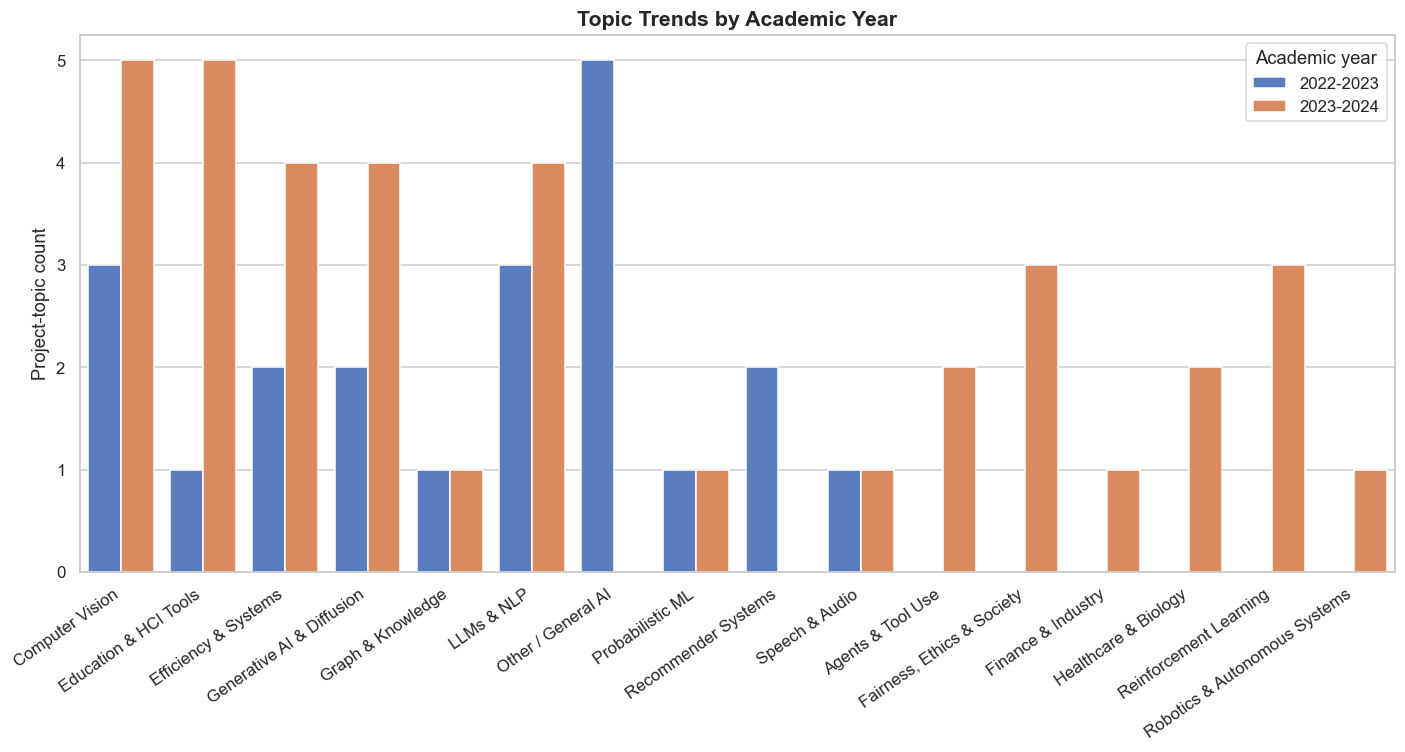

In [10]:
year_topic = (
    topics_extended.groupby(["academic_year", "topic"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=year_topic, x="topic", y="count", hue="academic_year", ax=ax)
ax.set_title("Topic Trends by Academic Year", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Project-topic count")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Academic year")
plt.tight_layout()
plt.show()

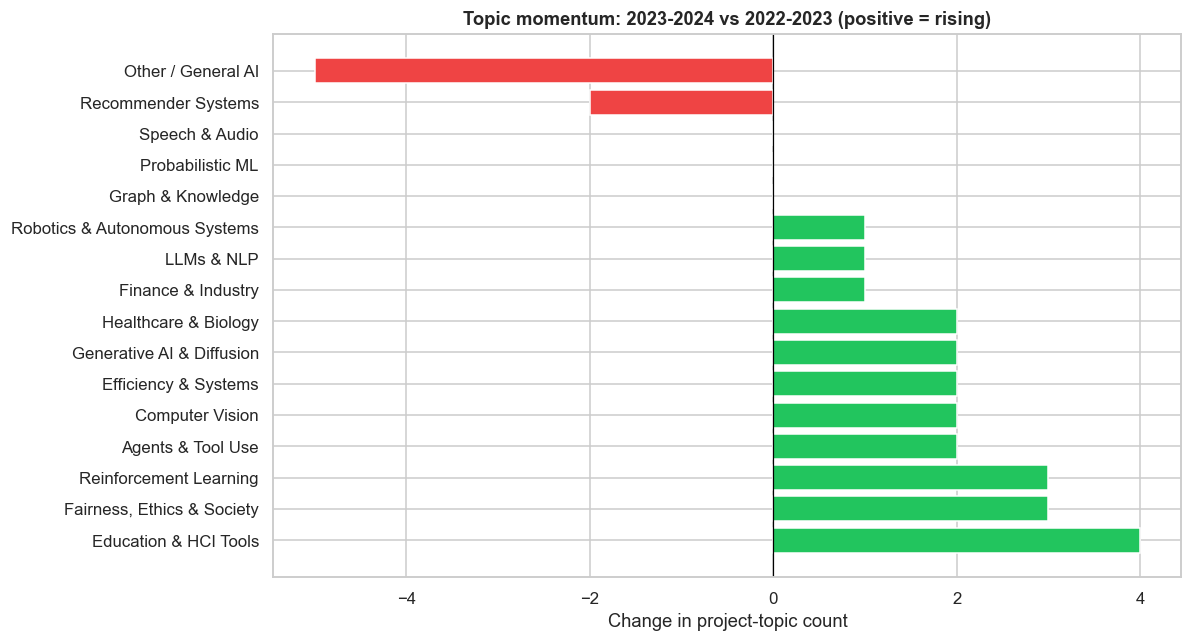

academic_year,2022-2023,2023-2024,delta
topic,,,
Education & HCI Tools,1.0,5.0,4.0
"Fairness, Ethics & Society",0.0,3.0,3.0
Reinforcement Learning,0.0,3.0,3.0
Agents & Tool Use,0.0,2.0,2.0
Computer Vision,3.0,5.0,2.0
Efficiency & Systems,2.0,4.0,2.0
Generative AI & Diffusion,2.0,4.0,2.0
Healthcare & Biology,0.0,2.0,2.0
Finance & Industry,0.0,1.0,1.0


In [11]:
pivot = year_topic.pivot(index="topic", columns="academic_year", values="count").fillna(0)
if pivot.shape[1] == 2:
    cols = sorted(pivot.columns)
    pivot["delta"] = pivot[cols[1]] - pivot[cols[0]]
    pivot = pivot.sort_values("delta", ascending=False)

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = ["#22c55e" if d >= 0 else "#ef4444" for d in pivot["delta"]]
    ax.barh(pivot.index, pivot["delta"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Topic momentum: {cols[1]} vs {cols[0]} (positive = rising)", fontweight="bold")
    ax.set_xlabel("Change in project-topic count")
    plt.tight_layout()
    plt.show()

display(pivot)

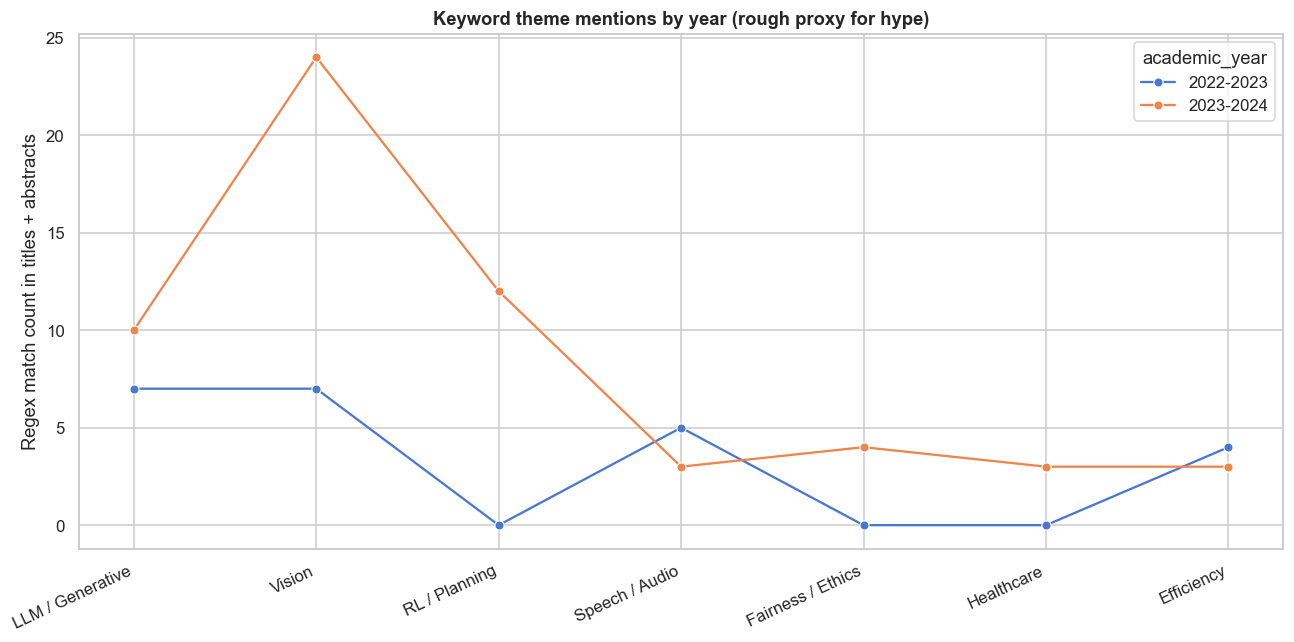

In [12]:
keyword_trends = {
    "LLM / Generative": r"\b(llm|language model|generative|diffusion|agent)\b",
    "Vision": r"\b(vision|image|3d|segmentation|detection|vit)\b",
    "RL / Planning": r"\b(reinforcement|policy|planning|decision)\b",
    "Speech / Audio": r"\b(speech|audio|spoken|translation)\b",
    "Fairness / Ethics": r"\b(fair|ethic|stereotype|bias|privacy|radical)\b",
    "Healthcare": r"\b(health|medical|clinical|polyp|patient)\b",
    "Efficiency": r"\b(efficient|caching|compress|quantiz|low-rank)\b",
}

trend_rows = []
for year, group in df_extended.groupby("academic_year"):
    blob = " ".join(group["title"].fillna("") + " " + group["abstract_snippet"].fillna("")).lower()
    for label, pattern in keyword_trends.items():
        trend_rows.append({
            "academic_year": year,
            "theme": label,
            "mentions": len(re.findall(pattern, blob)),
        })

trend_df = pd.DataFrame(trend_rows)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=trend_df, x="theme", y="mentions", hue="academic_year", marker="o", ax=ax)
ax.set_title("Keyword theme mentions by year (rough proxy for hype)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Regex match count in titles + abstracts")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 5. Match projects to *your* interests

Edit the cell below with topics and skills you care about. The notebook will:
- Rank existing projects by overlap
- Highlight **crowded** topics (many similar projects)
- Suggest **gap** topics (few/no outstanding projects)

In [14]:
# ✏️ EDIT THIS — add/remove items that describe what you want to work on
MY_INTERESTS = [
    "llm", "agents", "multimodal", "efficiency", "caching",
    "human-computer interaction", "tool use", "evaluation",
]

MY_SKILLS = [
    "python", "pytorch", "react", "web development", "nlp", "transformers",
]

AVOID_TOPICS = [
    "autonomous driving", "finance", "credit risk",
]

In [15]:
def score_project(row: pd.Series, interests: list[str], skills: list[str], avoid: list[str]) -> dict:
    blob = f"{row['title']} {row['abstract_snippet']} {row['topic_buckets']}".lower()
    interest_hits = [w for w in interests if w.lower() in blob]
    skill_hits = [w for w in skills if w.lower() in blob]
    avoid_hits = [w for w in avoid if w.lower() in blob]

    score = 2 * len(interest_hits) + len(skill_hits) - 3 * len(avoid_hits)
    return {
        "interest_hits": ", ".join(interest_hits) or "—",
        "skill_hits": ", ".join(skill_hits) or "—",
        "avoid_hits": ", ".join(avoid_hits) or "—",
        "match_score": score,
    }

scored = df_extended.copy()
scores = scored.apply(lambda r: score_project(r, MY_INTERESTS, MY_SKILLS, AVOID_TOPICS), axis=1, result_type="expand")
scored = pd.concat([scored, scores], axis=1).sort_values("match_score", ascending=False)

display_cols = ["match_score", "academic_year", "title", "topic_buckets", "interest_hits", "avoid_hits", "pdf_url"]
print("Top matches for your profile:\n")
display(scored[display_cols].head(10))

Top matches for your profile:



,match_score,academic_year,title,topic_buckets,interest_hits,avoid_hits,pdf_url
21,11,2023-2024,Reimagining Generative Agents: 3D Architecture,LLMs & NLP; Generative AI & Diffusion; Agents ...,"llm, agents, efficiency, caching, tool use",—,https://project-archive.inf.ed.ac.uk/msc/20247...
22,7,2023-2024,Hard-Routed Adapters: Enhancing API Calls in M...,LLMs & NLP; Agents & Tool Use,"llm, agents, tool use",—,https://project-archive.inf.ed.ac.uk/msc/20247...
11,5,2022-2023,Computationally Efficient Methods for Jointly ...,LLMs & NLP; Efficiency & Systems,"llm, efficiency",—,https://project-archive.inf.ed.ac.uk/msc/20236...
26,3,2023-2024,Shrill Girls and Soy Boys: Measuring Gender an...,"LLMs & NLP; Fairness, Ethics & Society",llm,—,https://project-archive.inf.ed.ac.uk/msc/20247...
25,3,2023-2024,Retrofitting Vision Transformers via Fixed and...,Computer Vision; Efficiency & Systems,efficiency,—,https://project-archive.inf.ed.ac.uk/msc/20247...
20,3,2023-2024,Scaling Pixel-based Language Models,LLMs & NLP; Generative AI & Diffusion,llm,—,https://project-archive.inf.ed.ac.uk/msc/20247...
1,3,2022-2023,Latent Diffusion Language Models,LLMs & NLP; Generative AI & Diffusion; Compute...,llm,—,https://project-archive.inf.ed.ac.uk/msc/20236...
4,3,2022-2023,Benchmarking Large Language AI Models for Machine,LLMs & NLP,llm,—,https://project-archive.inf.ed.ac.uk/msc/20236...
7,2,2022-2023,Self-Supervised Learning of Tractable Generati...,Generative AI & Diffusion; Probabilistic ML; E...,efficiency,—,https://project-archive.inf.ed.ac.uk/msc/20236...
27,2,2023-2024,Quantizing Tractable Probabilistic Models,Probabilistic ML; Efficiency & Systems,efficiency,—,https://project-archive.inf.ed.ac.uk/msc/20247...


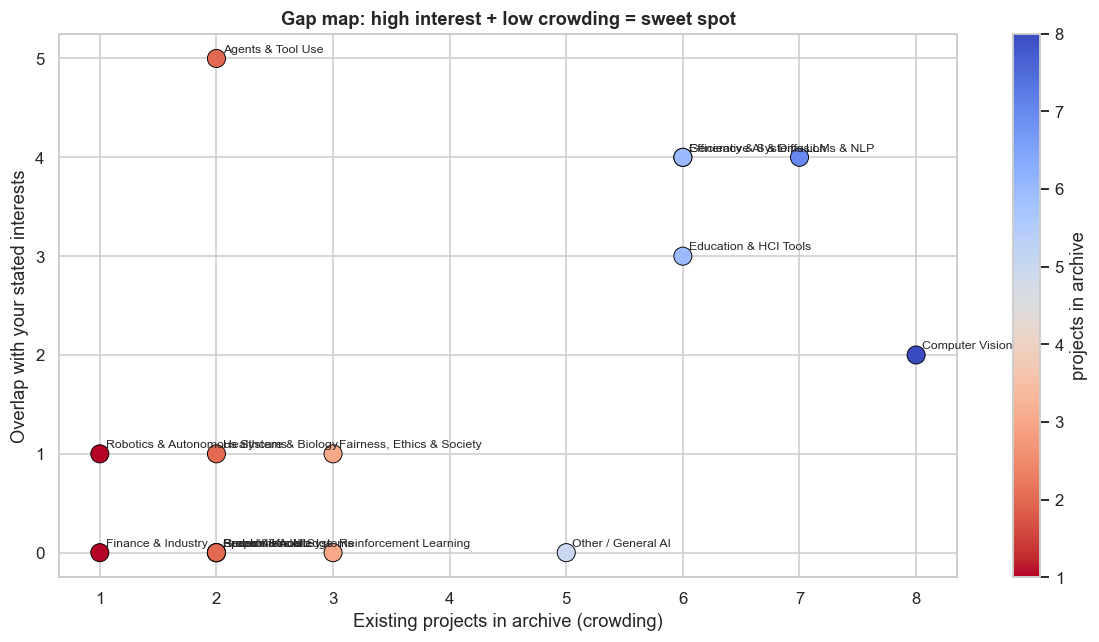


Suggested angles (high interest, low crowding):


,topic,projects_in_archive,interest_signal,crowding
0,Agents & Tool Use,2,5,moderate (2-3)
14,Robotics & Autonomous Systems,1,1,under-explored (0-1)
8,Healthcare & Biology,2,1,moderate (2-3)


In [16]:
all_topics = sorted(topics_extended["topic"].unique())
topic_popularity = topics_extended["topic"].value_counts()

interest_topic_rows = []
for topic in all_topics:
    topic_lower = topic.lower()
    interest_overlap = sum(1 for i in MY_INTERESTS if i in topic_lower or any(i in t.lower() for t in topic.split()))
    interest_overlap += sum(
        1 for i in MY_INTERESTS
        if any(i in str(row["title"]).lower() or i in str(row["abstract_snippet"]).lower()
               for _, row in df_extended[df_extended["topic_buckets"].str.contains(topic, na=False)].iterrows())
    )
    interest_topic_rows.append({
        "topic": topic,
        "projects_in_archive": int(topic_popularity.get(topic, 0)),
        "interest_signal": interest_overlap,
    })

gap_df = pd.DataFrame(interest_topic_rows)
gap_df["crowding"] = pd.cut(
    gap_df["projects_in_archive"],
    bins=[-1, 1, 3, 100],
    labels=["under-explored (0-1)", "moderate (2-3)", "crowded (4+)"],
)
gap_df = gap_df.sort_values(["interest_signal", "projects_in_archive"], ascending=[False, True])

fig, ax = plt.subplots(figsize=(11, 6))
scatter = ax.scatter(
    gap_df["projects_in_archive"],
    gap_df["interest_signal"],
    s=140,
    c=gap_df["projects_in_archive"],
    cmap="coolwarm_r",
    edgecolors="black",
    linewidths=0.6,
)
for _, row in gap_df.iterrows():
    ax.annotate(row["topic"], (row["projects_in_archive"], row["interest_signal"]),
                textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_xlabel("Existing projects in archive (crowding)")
ax.set_ylabel("Overlap with your stated interests")
ax.set_title("Gap map: high interest + low crowding = sweet spot", fontweight="bold")
plt.colorbar(scatter, label="projects in archive")
plt.tight_layout()
plt.show()

print("\nSuggested angles (high interest, low crowding):")
sweet = gap_df[(gap_df["interest_signal"] > 0) & (gap_df["projects_in_archive"] <= 2)]
display(sweet)

In [17]:
print("=" * 70)
print("QUICK TAKEAWAYS")
print("=" * 70)

top_topics = topics_recent["topic"].value_counts().head(5)
print("\nHottest buckets (2023-24):")
for topic, count in top_topics.items():
    print(f"  • {topic}: {count}")

if len(pivot) > 0 and "delta" in pivot.columns:
  rising = pivot[pivot["delta"] > 0].head(3)
  falling = pivot[pivot["delta"] < 0].tail(3)
  print("\nRising year-on-year:")
  for topic in rising.index:
      print(f"  ▲ {topic} (+{int(pivot.loc[topic, 'delta'])})")
  print("\nCooling off:")
  for topic in falling.index:
      print(f"  ▼ {topic} ({int(pivot.loc[topic, 'delta'])})")

print("\nYour top 3 closest existing projects:")
for _, row in scored.head(3).iterrows():
    print(f"  • [{row['match_score']}] {row['title'][:70]}")

QUICK TAKEAWAYS

Hottest buckets (2023-24):
  • Education & HCI Tools: 5
  • Computer Vision: 5
  • LLMs & NLP: 4
  • Generative AI & Diffusion: 4
  • Efficiency & Systems: 4

Rising year-on-year:
  ▲ Education & HCI Tools (+4)
  ▲ Fairness, Ethics & Society (+3)
  ▲ Reinforcement Learning (+3)

Cooling off:
  ▼ Recommender Systems (-2)
  ▼ Other / General AI (-5)

Your top 3 closest existing projects:
  • [11] Reimagining Generative Agents: 3D Architecture
  • [7] Hard-Routed Adapters: Enhancing API Calls in Multi-Agent
  • [5] Computationally Efficient Methods for Jointly Generating
